# 6CS012 - Tutorial 7: Denoising Convolutional Autoencoder
## Dataset: Devnagari Handwritten Digit Dataset
**Module:** Artificial Intelligence and Machine Learning (6CS012)  
**Prepared for:** Siman Giri | Module Leader - 6CS012

---

### Objective
Build a **Denoising Convolutional Autoencoder** (at least 4 layers deep) to remove Gaussian noise from Devnagari handwritten digit images.

### Pipeline
1. Dataset Preparation & Preprocessing  
2. Add Gaussian Noise  
3. Build the Convolutional Autoencoder (Encoder + Decoder, ≥ 4 conv layers)  
4. Train the Autoencoder  
5. Evaluate & Visualize Results  
6. Experiment & Fine-Tune

---
## Step 0: Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
SEED = 123
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


---
## Step 1: Dataset Preparation and Preprocessing

### 1.1 Load Devnagari Dataset using PIL

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/AI&ML/week4/DevanagariHandwrittenDigitDataset"   # root folder
TRAIN_DIR    = os.path.join(DATASET_PATH, "Train")
TEST_DIR     = os.path.join(DATASET_PATH, "Test")

IMG_SIZE     = (32, 32)   # resize all images to 32×32
IMG_CHANNELS = 1          # grayscale

def load_images_from_dir(root_dir, img_size=IMG_SIZE):
    """
    Walk through class sub-folders and load every image as a
    normalised grayscale NumPy array.

    Returns
    -------
    images : np.ndarray  shape (N, H, W, 1)  float32 in [0, 1]
    labels : np.ndarray  shape (N,)           int class indices
    """
    images, labels = [], []
    class_names = sorted(os.listdir(root_dir))

    for class_idx, class_name in enumerate(class_names):
        class_folder = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_folder):
            continue

        for fname in os.listdir(class_folder):
            if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            fpath = os.path.join(class_folder, fname)
            try:
                img = Image.open(fpath).convert("L")   # grayscale
                img = img.resize(img_size, Image.LANCZOS)
                arr = np.array(img, dtype="float32") / 255.0
                images.append(arr)
                labels.append(class_idx)
            except Exception as e:
                print(f"  [skip] {fpath}: {e}")

    images = np.array(images)[..., np.newaxis]   # add channel dim → (N,H,W,1)
    labels = np.array(labels)
    print(f"Loaded {len(images)} images from '{root_dir}'  "
          f"| classes: {len(class_names)}  | shape: {images.shape}")
    return images, labels


x_train_full, y_train_full = load_images_from_dir(TRAIN_DIR)
x_test,       y_test       = load_images_from_dir(TEST_DIR)

Loaded 17000 images from '/content/drive/MyDrive/AI&ML/week4/DevanagariHandwrittenDigitDataset/Train'  | classes: 10  | shape: (17000, 32, 32, 1)
Loaded 3000 images from '/content/drive/MyDrive/AI&ML/week4/DevanagariHandwrittenDigitDataset/Test'  | classes: 10  | shape: (3000, 32, 32, 1)


### 1.2 Train / Validation Split

In [ ]:
# 90 % train  |  10 % validation  (stratified to keep class balance)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.10,
    random_state=SEED,
    stratify=y_train_full
)

print(f"Train size      : {x_train.shape}")
print(f"Validation size : {x_val.shape}")
print(f"Test size       : {x_test.shape}")
print(f"Pixel range     : [{x_train.min():.2f}, {x_train.max():.2f}]")

Train size      : (15300, 32, 32, 1)
Validation size : (1700, 32, 32, 1)
Test size       : (3000, 32, 32, 1)
Pixel range     : [0.00, 1.00]


### 1.3 Visualise a Sample of Clean Images

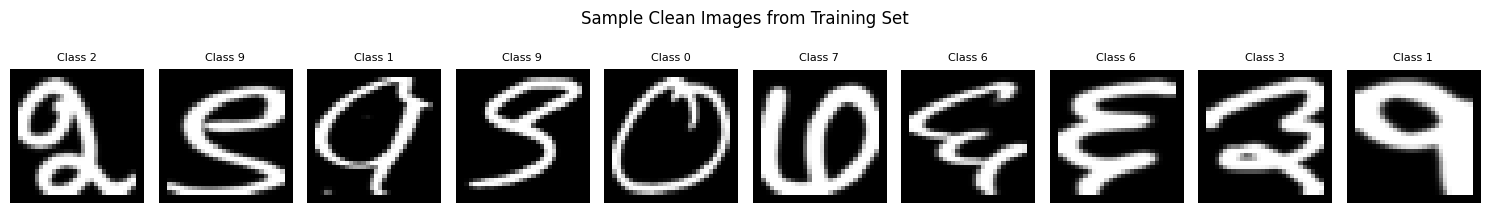

In [ ]:
n_show = 10
indices = np.random.choice(len(x_train), n_show, replace=False)

plt.figure(figsize=(15, 2))
for i, idx in enumerate(indices):
    ax = plt.subplot(1, n_show, i + 1)
    plt.imshow(x_train[idx].reshape(IMG_SIZE), cmap="gray")
    plt.title(f"Class {y_train[idx]}", fontsize=8)
    plt.axis("off")
plt.suptitle("Sample Clean Images from Training Set", y=1.05)
plt.tight_layout()
plt.show()

---
## Step 2: Add Gaussian Noise

We experiment with two noise factors:
- **Low noise** (`factor = 0.1`) – mild corruption  
- **High noise** (`factor = 0.4`) – heavy corruption (used to train the autoencoder)

In [ ]:
NOISE_FACTOR_LOW  = 0.1
NOISE_FACTOR_HIGH = 0.4

def add_gaussian_noise(images, noise_factor):
    """
    Add Gaussian noise to a batch of images and clip to [0, 1].

    Parameters
    ----------
    images       : np.ndarray  clean images  float32 [0,1]
    noise_factor : float       controls noise amplitude

    Returns
    -------
    noisy : np.ndarray  same shape as `images`, clipped to [0,1]
    """
    noise = noise_factor * np.random.normal(
        loc=0.0, scale=1.0, size=images.shape
    ).astype("float32")
    return np.clip(images + noise, 0.0, 1.0)


# ── Training set ────────────────────────────────────────────
x_train_noisy_low  = add_gaussian_noise(x_train, NOISE_FACTOR_LOW)
x_train_noisy_high = add_gaussian_noise(x_train, NOISE_FACTOR_HIGH)

# ── Validation set ──────────────────────────────────────────
x_val_noisy_low    = add_gaussian_noise(x_val,   NOISE_FACTOR_LOW)
x_val_noisy_high   = add_gaussian_noise(x_val,   NOISE_FACTOR_HIGH)

# ── Test set ────────────────────────────────────────────────
x_test_noisy_low   = add_gaussian_noise(x_test,  NOISE_FACTOR_LOW)
x_test_noisy_high  = add_gaussian_noise(x_test,  NOISE_FACTOR_HIGH)

print("Noisy datasets created.")
print(f"  Train noisy (high) shape : {x_train_noisy_high.shape}")

Noisy datasets created.
  Train noisy (high) shape : (15300, 32, 32, 1)


### 2.1 Visualise Noise Levels

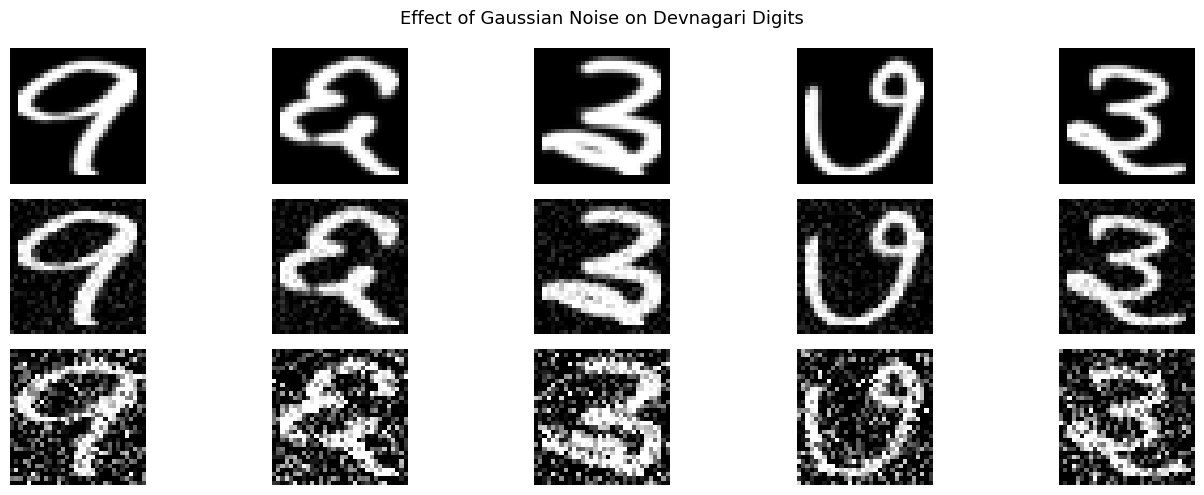

In [ ]:
n_show = 5
indices = np.random.choice(len(x_train), n_show, replace=False)

fig, axes = plt.subplots(3, n_show, figsize=(14, 5))
titles = ["Original", f"Noise={NOISE_FACTOR_LOW}", f"Noise={NOISE_FACTOR_HIGH}"]

for col, idx in enumerate(indices):
    for row, (img_set, title) in enumerate(zip(
        [x_train, x_train_noisy_low, x_train_noisy_high], titles
    )):
        axes[row, col].imshow(img_set[idx].reshape(IMG_SIZE), cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(title, fontsize=10, rotation=0,
                                      labelpad=80, va="center")

plt.suptitle("Effect of Gaussian Noise on Devnagari Digits", fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 3: Build the Denoising Convolutional Autoencoder

### Architecture Overview

In [ ]:
INPUT_SHAPE = (IMG_SIZE[0], IMG_SIZE[1], IMG_CHANNELS)   # (32, 32, 1)

# ──────────────────────────────────────────────────────────────
#  ENCODER
# ──────────────────────────────────────────────────────────────
def build_encoder(input_shape=INPUT_SHAPE):
    """
    Encoder: compresses input image into a compact latent representation.

    Architecture
    ─────────────
    [Conv2D-32 → BN → ReLU] → MaxPool  (layer 1)
    [Conv2D-64 → BN → ReLU] → MaxPool  (layer 2)  ← encoded output

    Parameters
    ----------
    input_shape : tuple  (H, W, C)

    Returns
    -------
    input_img : Keras Input tensor
    encoded   : Keras tensor  (latent feature map)
    """
    input_img = Input(shape=input_shape, name="encoder_input")

    # ── Encoder Layer 1 ────────────────────────────────────
    x = Conv2D(32, (3, 3), padding="same", name="enc_conv1")(input_img)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling2D((2, 2), padding="same")(x)    # 32×32 → 16×16

    # ── Encoder Layer 2 ────────────────────────────────────
    x = Conv2D(64, (3, 3), padding="same", name="enc_conv2")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    encoded = MaxPooling2D((2, 2), padding="same", name="latent")(x)  # 16×16 → 8×8

    return input_img, encoded


# ──────────────────────────────────────────────────────────────
#  DECODER
# ──────────────────────────────────────────────────────────────
def build_decoder(encoded_input):
    """
    Decoder: reconstructs the original image from the latent representation.

    Architecture
    ─────────────
    [Conv2D-64 → BN → ReLU] → UpSample  (layer 3)
    [Conv2D-32 → BN → ReLU] → UpSample  (layer 4)
    Conv2D-1  → Sigmoid                  (layer 5 – output)

    Parameters
    ----------
    encoded_input : Keras tensor  (latent feature map from encoder)

    Returns
    -------
    decoded : Keras tensor  (reconstructed image, same shape as input)
    """
    # ── Decoder Layer 3 ────────────────────────────────────
    x = Conv2D(64, (3, 3), padding="same", name="dec_conv1")(encoded_input)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = UpSampling2D((2, 2))(x)                    # 8×8 → 16×16

    # ── Decoder Layer 4 ────────────────────────────────────
    x = Conv2D(32, (3, 3), padding="same", name="dec_conv2")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = UpSampling2D((2, 2))(x)                    # 16×16 → 32×32

    # ── Decoder Layer 5 – output ───────────────────────────
    decoded = Conv2D(
        1, (3, 3), activation="sigmoid",
        padding="same", name="decoder_output"
    )(x)                                           # 32×32×1  pixels in [0,1]

    return decoded


# ──────────────────────────────────────────────────────────────
#  FULL AUTOENCODER
# ──────────────────────────────────────────────────────────────
def build_autoencoder(input_shape=INPUT_SHAPE, learning_rate=1e-3):
    """
    Assembles and compiles the full denoising convolutional autoencoder.

    Loss     : binary_crossentropy (pixel values normalised to [0,1])
    Optimizer: Adam
    Metric   : Mean Absolute Error (useful to track reconstruction quality)

    Returns
    -------
    autoencoder : compiled Keras Model
    """
    input_img, encoded_output = build_encoder(input_shape)
    decoded_output            = build_decoder(encoded_output)

    autoencoder = Model(
        inputs=input_img, outputs=decoded_output, name="denoising_autoencoder"
    )
    autoencoder.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["mae"]
    )
    return autoencoder


autoencoder = build_autoencoder()
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (MaxPooling2D)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,265 (294.00 KB)

 Trainable params: 74,881 (292.50 KB)

 Non-trainable params: 384 (1.50 KB)

---
## Step 4: Train the Autoencoder

- **Input** : noisy images (`x_train_noisy_high`)
- **Target**: clean images (`x_train`)
- **Callbacks** used:
  - `EarlyStopping` – stops when validation loss stops improving (patience = 10)
  - `ReduceLROnPlateau` – halves learning rate if loss plateaus (patience = 5)

In [ ]:
EPOCHS     = 50
BATCH_SIZE = 64

callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=10,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    )
]

history = autoencoder.fit(
    x_train_noisy_high, x_train,          # noisy input → clean target
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_val_noisy_high, x_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 84s 332ms/step - loss: 0.1726 - mae: 0.0705 - val_loss: 0.6625 - val_mae: 0.2120 - learning_rate: 0.0010
Epoch 2/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 81s 335ms/step - loss: 0.1378 - mae: 0.0422 - val_loss: 0.1453 - val_mae: 0.0453 - learning_rate: 0.0010
Epoch 3/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 82s 336ms/step - loss: 0.1345 - mae: 0.0394 - val_loss: 0.1354 - val_mae: 0.0385 - learning_rate: 0.0010
Epoch 4/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 79s 330ms/step - loss: 0.1328 - mae: 0.0380 - val_loss: 0.1341 - val_mae: 0.0374 - learning_rate: 0.0010
Epoch 5/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 83s 334ms/step - loss: 0.1317 - mae: 0.0371 - val_loss: 0.1335 - val_mae: 0.0368 - learning_rate: 0.0010
Epoch 6/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 83s 337ms/step - loss: 0.1309 - mae: 0.0364 - val_loss: 0.1328 - val_mae: 0.0364 - learning_rate: 0.0010
Epoch 7/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 82s 339ms/step - loss: 0.1303 - mae: 0.0359 - val_loss: 0.1321 - val_mae: 0.0359 - learnin

### 4.1 Plot Training & Validation Loss

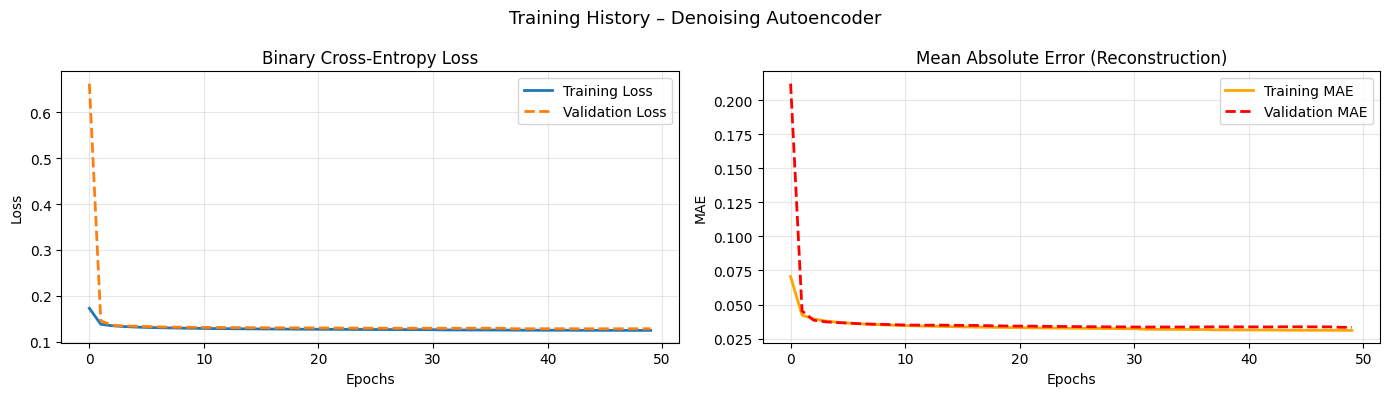

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Binary Cross-Entropy Loss ──────────────────────────────
axes[0].plot(history.history["loss"],     label="Training Loss",   linewidth=2)
axes[0].plot(history.history["val_loss"], label="Validation Loss", linewidth=2, linestyle="--")
axes[0].set_title("Binary Cross-Entropy Loss", fontsize=12)
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Mean Absolute Error ────────────────────────────────────
axes[1].plot(history.history["mae"],     label="Training MAE",   linewidth=2, color="orange")
axes[1].plot(history.history["val_mae"], label="Validation MAE", linewidth=2, linestyle="--", color="red")
axes[1].set_title("Mean Absolute Error (Reconstruction)", fontsize=12)
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Training History – Denoising Autoencoder", fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 5: Evaluate and Visualise Results

### 5.1 Quantitative Evaluation

In [ ]:
test_loss, test_mae = autoencoder.evaluate(
    x_test_noisy_high, x_test, verbose=0
)
print(f"Test Binary Cross-Entropy Loss : {test_loss:.4f}")
print(f"Test Mean Absolute Error       : {test_mae:.4f}")

Test Binary Cross-Entropy Loss : 0.1273
Test Mean Absolute Error       : 0.0333


### 5.2 Visual Comparison – Noisy | Denoised | Clean

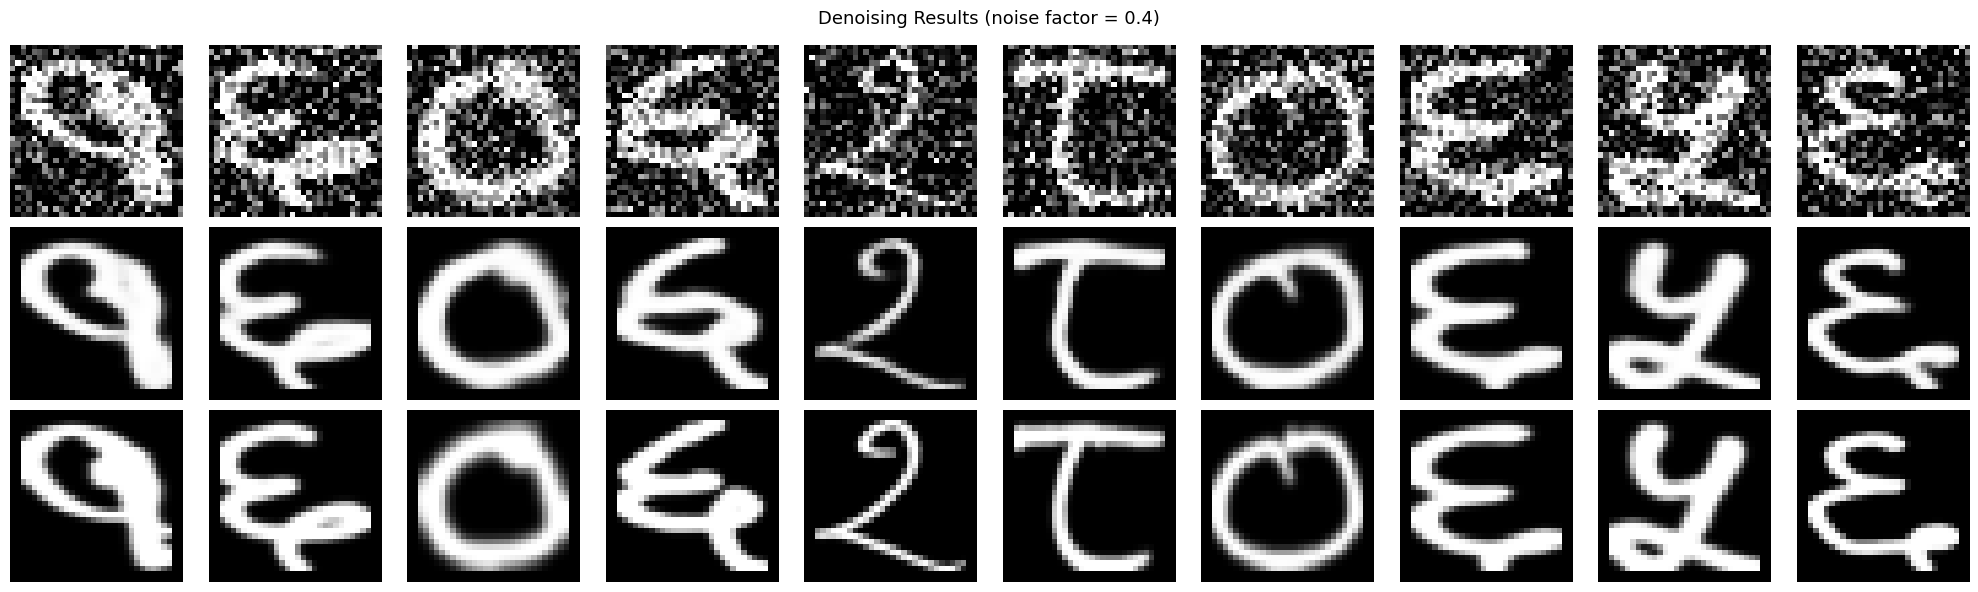

In [ ]:
denoised_images = autoencoder.predict(x_test_noisy_high, verbose=0)

def plot_comparison(noisy, denoised, clean, n=10, title=""):
    """
    Display three rows: noisy | denoised | clean images.

    Parameters
    ----------
    noisy    : np.ndarray  noisy test images
    denoised : np.ndarray  model predictions
    clean    : np.ndarray  original clean images
    n        : int         number of samples to display
    title    : str         figure title
    """
    fig, axes = plt.subplots(3, n, figsize=(2 * n, 6))
    row_labels = ["Noisy Input", "Denoised Output", "Clean Target"]

    indices = np.random.choice(len(clean), n, replace=False)

    for col, idx in enumerate(indices):
        for row, img_set in enumerate([noisy, denoised, clean]):
            axes[row, col].imshow(
                img_set[idx].reshape(IMG_SIZE), cmap="gray", vmin=0, vmax=1
            )
            axes[row, col].axis("off")
        if col == 0:
            for row in range(3):
                axes[row, 0].set_ylabel(
                    row_labels[row], fontsize=9, rotation=0,
                    labelpad=90, va="center"
                )

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


plot_comparison(
    x_test_noisy_high, denoised_images, x_test, n=10,
    title=f"Denoising Results (noise factor = {NOISE_FACTOR_HIGH})"
)

### 5.3 Pixel-Level Residual Analysis

The residual (absolute difference between clean and denoised) lets us see where the model still struggles.

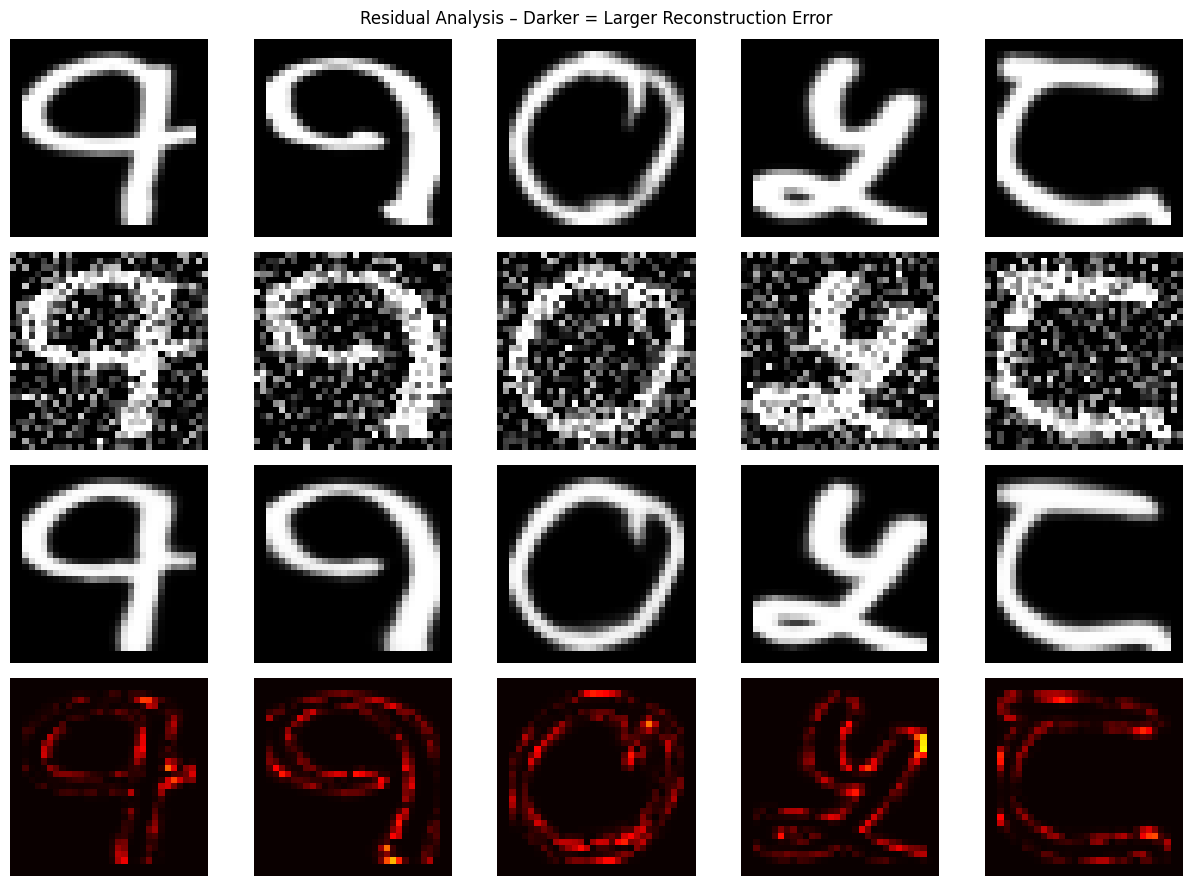

Mean pixel residual (test set): 0.0333


In [ ]:
n = 5
indices = np.random.choice(len(x_test), n, replace=False)
residuals = np.abs(x_test - denoised_images)         # pixel-wise error

fig, axes = plt.subplots(4, n, figsize=(2.5 * n, 9))
row_labels = ["Clean", "Noisy", "Denoised", "Residual |Clean−Denoised|"]

for col, idx in enumerate(indices):
    for row, (img_set, cmap) in enumerate(zip(
        [x_test, x_test_noisy_high, denoised_images, residuals],
        ["gray", "gray", "gray", "hot"]
    )):
        axes[row, col].imshow(img_set[idx].reshape(IMG_SIZE), cmap=cmap, vmin=0, vmax=1)
        axes[row, col].axis("off")
    if col == 0:
        for row in range(4):
            axes[row, 0].set_ylabel(
                row_labels[row], fontsize=8, rotation=0,
                labelpad=100, va="center"
            )

plt.suptitle("Residual Analysis – Darker = Larger Reconstruction Error", fontsize=12)
plt.tight_layout()
plt.show()

mean_residual = residuals.mean()
print(f"Mean pixel residual (test set): {mean_residual:.4f}")

---
## Step 6: Experiment & Fine-Tune

### 6.1 Compare Noise Levels – Low vs High

MAE on low-noise  images (factor=0.1)  : 0.0207
MAE on high-noise images (factor=0.4) : 0.0333


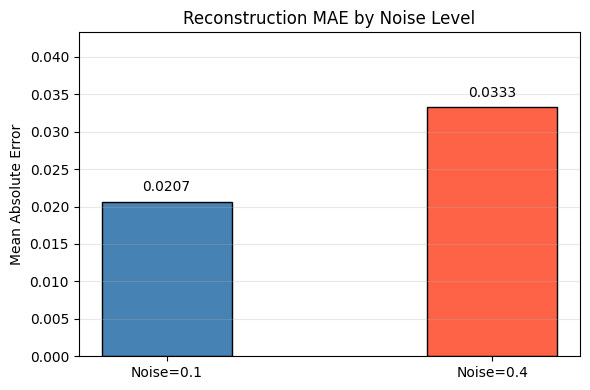

In [ ]:
denoised_low  = autoencoder.predict(x_test_noisy_low,  verbose=0)
denoised_high = autoencoder.predict(x_test_noisy_high, verbose=0)

mae_low  = np.abs(x_test - denoised_low).mean()
mae_high = np.abs(x_test - denoised_high).mean()

print(f"MAE on low-noise  images (factor={NOISE_FACTOR_LOW})  : {mae_low:.4f}")
print(f"MAE on high-noise images (factor={NOISE_FACTOR_HIGH}) : {mae_high:.4f}")

# Bar chart comparison
plt.figure(figsize=(6, 4))
bars = plt.bar(
    [f"Noise={NOISE_FACTOR_LOW}", f"Noise={NOISE_FACTOR_HIGH}"],
    [mae_low, mae_high],
    color=["steelblue", "tomato"], width=0.4, edgecolor="black"
)
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{bar.get_height():.4f}",
        ha="center", va="bottom", fontsize=10
    )
plt.title("Reconstruction MAE by Noise Level", fontsize=12)
plt.ylabel("Mean Absolute Error")
plt.ylim(0, max(mae_low, mae_high) * 1.3)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 Deeper Architecture Experiment

We build a **6-conv-layer** (3 encoder + 3 decoder) variant and compare test MAE.

In [ ]:
def build_deeper_autoencoder(input_shape=INPUT_SHAPE, learning_rate=1e-3):
    """
    A deeper variant with 6 convolutional layers (3 encoder + 3 decoder).
    Bottleneck: 4×4×128.

    Returns
    -------
    model : compiled Keras Model
    """
    inp = Input(shape=input_shape, name="deep_input")

    # ── ENCODER ────────────────────────────────────────────
    x = Conv2D(32, (3, 3), activation="relu", padding="same")(inp)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding="same")(x)        # 32→16

    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding="same")(x)        # 16→8

    x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    encoded = MaxPooling2D((2, 2), padding="same", name="deep_latent")(x)  # 8→4

    # ── DECODER ────────────────────────────────────────────
    x = Conv2D(128, (3, 3), activation="relu", padding="same")(encoded)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2))(x)                        # 4→8

    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2))(x)                        # 8→16

    x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2))(x)                        # 16→32

    out = Conv2D(1, (3, 3), activation="sigmoid", padding="same",
                 name="deep_output")(x)

    model = Model(inputs=inp, outputs=out, name="deeper_autoencoder")
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["mae"]
    )
    return model


deeper_ae = build_deeper_autoencoder()
deeper_ae.summary()

Model: "deeper_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ deep_input (InputLayer)         │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_latent (MaxPooling2D)      │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_output (Conv2D)            │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 334,593 (1.28 MB)

 Trainable params: 333,697 (1.27 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
history_deep = deeper_ae.fit(
    x_train_noisy_high, x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_val_noisy_high, x_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 123s 467ms/step - loss: 0.2388 - mae: 0.1126 - val_loss: 1.0037 - val_mae: 0.2348 - learning_rate: 0.0010
Epoch 2/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 109s 455ms/step - loss: 0.1505 - mae: 0.0513 - val_loss: 0.1637 - val_mae: 0.0640 - learning_rate: 0.0010
Epoch 3/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 142s 455ms/step - loss: 0.1430 - mae: 0.0457 - val_loss: 0.1445 - val_mae: 0.0461 - learning_rate: 0.0010
Epoch 4/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 144s 462ms/step - loss: 0.1393 - mae: 0.0429 - val_loss: 0.1418 - val_mae: 0.0436 - learning_rate: 0.0010
Epoch 5/50
239/240 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - loss: 0.1374 - mae: 0.0415
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
240/240 ━━━━━━━━━━━━━━━━━━━━ 112s 467ms/step - loss: 0.1368 - mae: 0.0410 - val_loss: 0.1405 - val_mae: 0.0426 - learning_rate: 0.0010
Epoch 6/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 113s 472ms/step - loss: 0.1336 - mae: 0.0386 - val_loss: 0.1391 - val_mae: 0.0425 

In [ ]:
_, test_mae_shallow = autoencoder.evaluate(x_test_noisy_high, x_test, verbose=0)
_, test_mae_deep    = deeper_ae.evaluate(  x_test_noisy_high, x_test, verbose=0)

print(f"\nModel Comparison (noise factor = {NOISE_FACTOR_HIGH})")
print(f"{'Model':<25} {'Test MAE':>10}")
print("-" * 36)
print(f"{'Baseline  (5 conv)' :<25} {test_mae_shallow:>10.4f}")
print(f"{'Deeper    (7 conv)' :<25} {test_mae_deep:>10.4f}")


Model Comparison (noise factor = 0.4)
Model                       Test MAE
------------------------------------
Baseline  (5 conv)            0.0333
Deeper    (7 conv)            0.2350


### 6.3 Visual Results – Deeper Model

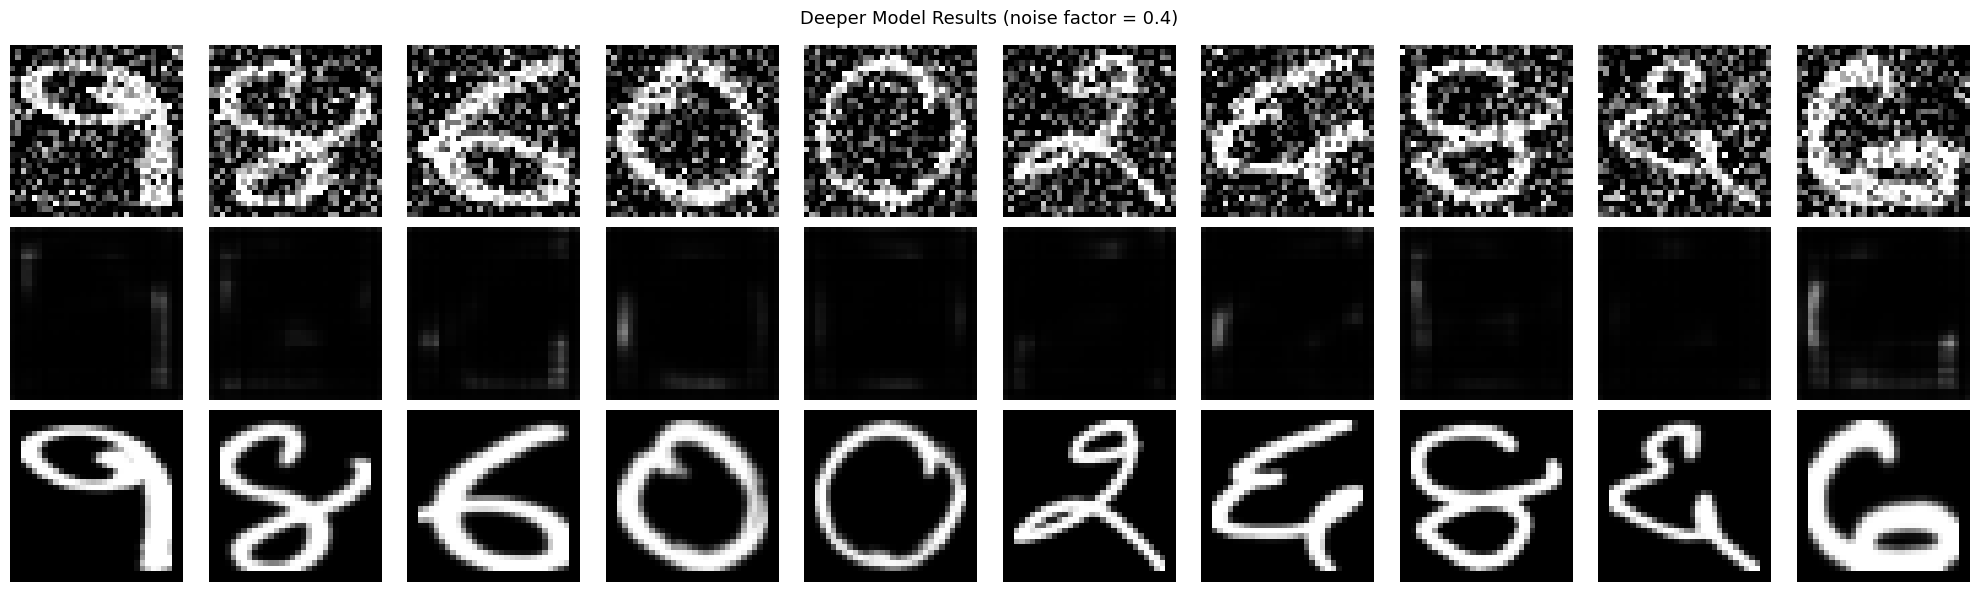

In [ ]:
denoised_deep = deeper_ae.predict(x_test_noisy_high, verbose=0)

plot_comparison(
    x_test_noisy_high, denoised_deep, x_test, n=10,
    title=f"Deeper Model Results (noise factor = {NOISE_FACTOR_HIGH})"
)

## Summary

This tutorial successfully implemented and trained a Denoising Convolutional Autoencoder to remove Gaussian noise from Devnagari handwritten digit images. Key observations include:

*   The baseline autoencoder (5 convolutional layers) effectively denoised images with a high noise factor (0.4), achieving a Test Mean Absolute Error (MAE) of 0.0333.
*   As expected, the trained model performed even better on images with a lower noise factor (0.1), yielding an MAE of 0.0207.
*   An experiment with a deeper autoencoder (7 convolutional layers) showed a significantly worse performance (Test MAE: 0.2350) and suffered from early stopping, suggesting that increasing depth without further hyperparameter tuning or regularization may not always improve results and can lead to overfitting or training instability in this context.